# OpenSqray Real SDPC Tutorial

这个 notebook 演示如何用 OpenSqray 读取本地 `data/` 目录中的真实 SDPC 文件。默认输入是 `data/20220514_145829_0.sdpc`；也可以通过环境变量 `OPENSQRAY_TUTORIAL_SDPC` 指向其他 SDPC 文件。

公开仓库不会提交 `data/` 里的完整真实切片文件。本 notebook 提交的是真实执行输出：文件存在性、元数据、associated image 候选、真实 associated-image 预览图、CLI 结果和当前 native tile-read 边界。`20220514_145829_0.sdpc` 是公开样本，因此这里可以展示它导出的轻量预览图。

## 1. 环境与导入

在源码仓库中运行时，下面的代码会把 `src/` 加入 `sys.path`。

In [1]:
from pathlib import Path
import io
import json
import os
import shutil
import subprocess
import sys

try:
    from IPython.display import display
except ImportError:
    display = None

REPO_ROOT = Path.cwd().resolve()
sys.path.insert(0, str(REPO_ROOT / "src"))

from opensqray import SDPCSlide
from opensqray.sdpc import extract_sdpc_associated_images, read_sdpc

try:
    from PIL import Image
except ImportError:
    Image = None

print("repo: current checkout")
print(f"python: {sys.version.split()[0]}")
print(f"pillow_available: {Image is not None}")

repo: current checkout
python: 3.13.12
pillow_available: True


## 2. 选择真实 SDPC 文件

默认读取仓库外部忽略的 `data/20220514_145829_0.sdpc`。如果你想测试自己的文件，设置 `OPENSQRAY_TUTORIAL_SDPC=/path/to/file.sdpc` 后重新运行 notebook。

In [2]:
default_sdpc = Path("data/20220514_145829_0.sdpc")
slide_path = Path(os.environ.get("OPENSQRAY_TUTORIAL_SDPC", str(default_sdpc)))

if not slide_path.exists():
    raise FileNotFoundError(
        f"SDPC file not found: {slide_path}. Put a real SDPC file under data/ "
        "or set OPENSQRAY_TUTORIAL_SDPC."
    )

file_info = {
    "path": str(slide_path),
    "file_size_bytes": slide_path.stat().st_size,
    "file_size_mib": round(slide_path.stat().st_size / 1024 / 1024, 2),
    "from_env": "OPENSQRAY_TUTORIAL_SDPC" in os.environ,
}
print(json.dumps(file_info, indent=2, ensure_ascii=False))

{
  "path": "data/20220514_145829_0.sdpc",
  "file_size_bytes": 22843585,
  "file_size_mib": 21.79,
  "from_env": false
}


## 3. 解析真实 SDPC metadata

`read_sdpc()` 会读取真实文件头、metadata 字符串和 JPEG 记录 preview。

In [3]:
info = read_sdpc(slide_path, scan_jpegs=False, jpeg_preview_limit=20)
payload = info.to_dict()
summary = {
    "schema_version": payload["schema_version"],
    "version": payload["version"],
    "dimensions": payload["dimensions"],
    "level_count": payload["level_count"],
    "tile_size": payload["tile_size"],
    "thumbnail_size": payload["thumbnail_size"],
    "scan_magnification": payload["scan_magnification"],
    "metadata": payload["metadata"],
    "warnings": payload["validation"]["warnings"],
}
print(json.dumps(summary, indent=2, ensure_ascii=False))

{
  "schema_version": "opensqray.sdpc.metadata.v1",
  "version": "SQ1.1.9.0430",
  "dimensions": {
    "width": 26880,
    "height": 21504
  },
  "level_count": 4,
  "tile_size": {
    "width": 672,
    "height": 672
  },
  "thumbnail_size": {
    "width": 302,
    "height": 241
  },
  "scan_magnification": 40,
  "metadata": {
    "device_id": "FV-025GN-X1C",
    "acquired_at": "2022/5/14 14:58:34",
    "scanner_model": "SQS120P-20220006",
    "objective": "UPlanApo40X",
    "embedded_strings": [
      "FV-025GN-X1C",
      "k>qm",
      "?2022/5/14 14:58:34",
      "SQS120P-20220006",
      "UPlanApo40X"
    ]
  },
  "warnings": []
}


## 4. Associated image 候选

这个真实 SDPC 文件可以解析出 associated image 候选。候选角色名仍是启发式命名，不等同于已确认的官方 SDPC directory entry。下面先导出候选 JPEG，再显示从公开样本得到的真实预览图。

In [4]:
associated_records = [
    {
        "name": record["name"],
        "record_index": record["record_index"],
        "dimensions": record["dimensions"],
        "byte_length": record["length"],
        "confidence": record["confidence"],
    }
    for record in payload["associated_images"]["records"]
]
print(json.dumps(associated_records, indent=2, ensure_ascii=False))

[
  {
    "name": "label_candidate",
    "record_index": 0,
    "dimensions": {
      "width": 992,
      "height": 1040
    },
    "byte_length": 42872,
    "confidence": "heuristic"
  },
  {
    "name": "macro_candidate",
    "record_index": 1,
    "dimensions": {
      "width": 1872,
      "height": 1040
    },
    "byte_length": 77727,
    "confidence": "heuristic"
  }
]


In [5]:
workdir = Path("/tmp/opensqray_real_tutorial")
associated_dir = workdir / "associated"
if associated_dir.exists():
    shutil.rmtree(associated_dir)

extracted = extract_sdpc_associated_images(slide_path, associated_dir, jpeg_preview_limit=20)
extracted_summary = [
    {
        "name": item["name"],
        "output_name": Path(item["output_path"]).name,
        "byte_length": Path(item["output_path"]).stat().st_size,
    }
    for item in extracted
]
print(json.dumps(extracted_summary, indent=2, ensure_ascii=False))

[
  {
    "name": "label_candidate",
    "output_name": "20220514_145829_0-0000-label_candidate.jpg",
    "byte_length": 42872
  },
  {
    "name": "macro_candidate",
    "output_name": "20220514_145829_0-0001-macro_candidate.jpg",
    "byte_length": 77727
  }
]


[
  {
    "name": "label_candidate",
    "mode": "RGB",
    "size": [
      992,
      1040
    ]
  },
  {
    "name": "macro_candidate",
    "mode": "RGB",
    "size": [
      1872,
      1040
    ]
  }
]
label_candidate preview:


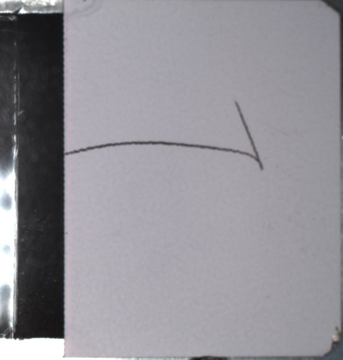

macro_candidate preview:


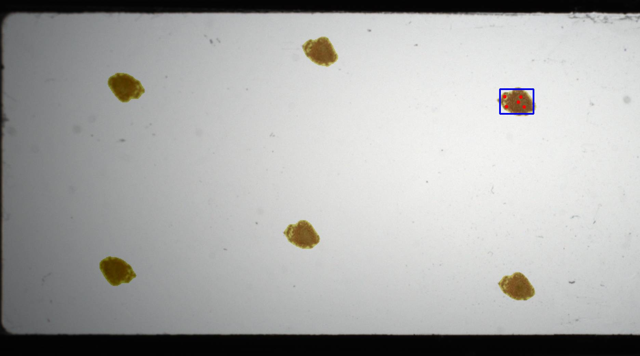

In [6]:
if Image is None:
    print("Pillow is not installed; skip JPEG decode and preview display.")
else:
    decoded = []
    previews = []
    for item in extracted:
        image = Image.open(item["output_path"])
        decoded.append({
            "name": item["name"],
            "mode": image.mode,
            "size": image.size,
        })
        preview = image.copy()
        preview.thumbnail((640, 360))
        previews.append((item["name"], preview))

    print(json.dumps(decoded, indent=2, ensure_ascii=False))
    if display is None:
        print(f"IPython display is not available; preview JPEGs are in {associated_dir}.")
    else:
        for name, preview in previews:
            print(f"{name} preview:")
            display(preview)

## 5. `SDPCSlide` facade

`SDPCSlide` 提供 OpenSlide-like metadata 属性和 candidate byte 读取。

In [7]:
with SDPCSlide(slide_path, jpeg_preview_limit=20) as slide:
    facade_summary = {
        "dimensions": slide.dimensions,
        "level_count": slide.level_count,
        "level_dimensions": slide.level_dimensions,
        "level_downsamples": slide.level_downsamples,
        "backend": slide.properties["opensqray.backend"],
        "associated_names": sorted(slide.associated_images),
    }
    first_name = facade_summary["associated_names"][0]
    first_bytes = slide.read_associated_image_bytes(first_name)
    facade_summary["first_associated_name"] = first_name
    facade_summary["first_associated_bytes"] = len(first_bytes)

print(json.dumps(facade_summary, indent=2, ensure_ascii=False))

{
  "dimensions": [
    26880,
    21504
  ],
  "level_count": 4,
  "level_dimensions": [
    [
      26880,
      21504
    ],
    [
      13440,
      10752
    ],
    [
      6720,
      5376
    ],
    [
      3360,
      2688
    ]
  ],
  "level_downsamples": [
    1.0,
    2.0,
    4.0,
    8.0
  ],
  "backend": "native",
  "associated_names": [
    "label_candidate",
    "macro_candidate"
  ],
  "first_associated_name": "label_candidate",
  "first_associated_bytes": 42872
}


## 6. Tile-index 真实结果

这个 22MB SDPC 文件可以验证 metadata 和 associated image 流程；但当前 native preview 没有发现 tile-sized JPEG record，所以 `tile_index.status` 是 `unavailable`。这不是隐藏失败，而是当前 native parser 对该真实样本的边界。

In [8]:
tile_index = payload["tile_index"]
tile_summary = {
    "status": tile_index["status"],
    "confidence": tile_index["confidence"],
    "expected_tile_count": tile_index["expected_tile_count"],
    "observed_tile_count": tile_index["observed_tile_count"],
    "preview_limited": tile_index["preview_limited"],
    "levels": tile_index["levels"],
    "limitations": tile_index["limitations"],
}
print(json.dumps(tile_summary, indent=2, ensure_ascii=False))

{
  "status": "unavailable",
  "confidence": "unavailable",
  "expected_tile_count": 1700,
  "observed_tile_count": 0,
  "preview_limited": false,
  "levels": [
    {
      "level": 0,
      "dimensions": {
        "width": 26880,
        "height": 21504
      },
      "grid": {
        "columns": 40,
        "rows": 32
      },
      "expected_tiles": 1280,
      "first_sequence_index": 0,
      "last_sequence_index": 1279
    },
    {
      "level": 1,
      "dimensions": {
        "width": 13440,
        "height": 10752
      },
      "grid": {
        "columns": 20,
        "rows": 16
      },
      "expected_tiles": 320,
      "first_sequence_index": 1280,
      "last_sequence_index": 1599
    },
    {
      "level": 2,
      "dimensions": {
        "width": 6720,
        "height": 5376
      },
      "grid": {
        "columns": 10,
        "rows": 8
      },
      "expected_tiles": 80,
      "first_sequence_index": 1600,
      "last_sequence_index": 1679
    },
    {
      "leve

## 7. CLI 真实执行

下面直接调用 OpenSqray CLI 读取同一个真实 SDPC 文件。

In [9]:
env = {**os.environ, "PYTHONPATH": str(REPO_ROOT / "src")}

def run_cli(args: list[str]) -> subprocess.CompletedProcess[str]:
    return subprocess.run(
        [sys.executable, "-m", "opensqray.cli", *args],
        cwd=REPO_ROOT,
        env=env,
        text=True,
        capture_output=True,
        check=False,
    )

def display_cmd(args: list[str]) -> str:
    return "python -m opensqray.cli " + " ".join(args)

inspect_args = ["inspect", str(slide_path), "--compact"]
result = run_cli(inspect_args)
inspect_payload = json.loads(result.stdout) if result.stdout else {}
cli_summary = {
    "command": display_cmd(inspect_args),
    "exit_code": result.returncode,
    "format": inspect_payload.get("format"),
    "schema_version": inspect_payload.get("schema_version"),
    "dimensions": inspect_payload.get("dimensions"),
    "associated_count": inspect_payload.get("associated_images", {}).get("count"),
    "tile_index_status": inspect_payload.get("tile_index", {}).get("status"),
    "stderr": result.stderr.strip(),
}
print(json.dumps(cli_summary, indent=2, ensure_ascii=False))

{
  "command": "python -m opensqray.cli inspect data/20220514_145829_0.sdpc --compact",
  "exit_code": 0,
  "format": "sdpc",
  "schema_version": "opensqray.sdpc.metadata.v1",
  "dimensions": {
    "height": 21504,
    "width": 26880
  },
  "associated_count": 2,
  "tile_index_status": "unavailable",
  "stderr": ""
}


In [10]:
associated_args = ["associated", str(slide_path), "--compact"]
result = run_cli(associated_args)
associated_payload = json.loads(result.stdout) if result.stdout else {}
cli_associated = {
    "command": display_cmd(associated_args),
    "exit_code": result.returncode,
    "count": associated_payload.get("count"),
    "names": [record.get("name") for record in associated_payload.get("records", [])],
    "stderr": result.stderr.strip(),
}
print(json.dumps(cli_associated, indent=2, ensure_ascii=False))

{
  "command": "python -m opensqray.cli associated data/20220514_145829_0.sdpc --compact",
  "exit_code": 0,
  "count": 2,
  "names": [
    "label_candidate",
    "macro_candidate"
  ],
  "stderr": ""
}

In [11]:
tile_args = [
    "read-tile", str(slide_path),
    "--backend", "native",
    "--preview-limit", "20",
    "--level", "0",
    "--tile-x", "0",
    "--tile-y", "0",
    "--output", str(workdir / "native-tile.jpg"),
    "--overwrite",
    "--compact",
]
result = run_cli(tile_args)
print(json.dumps({
    "command": display_cmd(tile_args),
    "exit_code": result.returncode,
    "stdout": result.stdout.strip(),
    "stderr": result.stderr.strip(),
    "expected_for_this_sample": "native tile read is unavailable because no tile-sized JPEG candidate was found",
}, indent=2, ensure_ascii=False))

{
  "command": "python -m opensqray.cli read-tile data/20220514_145829_0.sdpc --backend native --preview-limit 20 --level 0 --tile-x 0 --tile-y 0 --output /tmp/opensqray_real_tutorial/native-tile.jpg --overwrite --compact",
  "exit_code": 2,
  "stdout": "",
  "stderr": "opensqray: 'tile JPEG candidate is not present in the current preview; increase jpeg_preview_limit or wait for formal SDPC tile-index mapping'",
  "expected_for_this_sample": "native tile read is unavailable because no tile-sized JPEG candidate was found"
}


## 8. SDK 后端说明

如果你配置了合法 Sqray SDK runtime，可以用同一个真实 SDPC 文件测试 SDK 后端：

```python
with SDPCSlide(slide_path, backend="sdk") as slide:
    tile_jpeg = slide.read_tile_jpeg_bytes(level=0, tile_x=0, tile_y=0)
    region = slide.read_region((0, 0), 0, (512, 512))
```

公开 notebook 不会自动加载或分发专有 SDK。

In [12]:
sdk_env = {
    "OPENSQRAY_SDK_LIB_DIR": bool(os.environ.get("OPENSQRAY_SDK_LIB_DIR")),
    "OPENSQRAY_SDK_DIR": bool(os.environ.get("OPENSQRAY_SDK_DIR")),
    "OPENSQRAY_SDK_EXTRA_LIB_DIRS": bool(os.environ.get("OPENSQRAY_SDK_EXTRA_LIB_DIRS")),
}
print(json.dumps(sdk_env, indent=2))

{
  "OPENSQRAY_SDK_LIB_DIR": false,
  "OPENSQRAY_SDK_DIR": false,
  "OPENSQRAY_SDK_EXTRA_LIB_DIRS": false
}
